In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_excel("sales_data.xlsx")

In [13]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order ID  3 non-null      int64         
 1   Date      3 non-null      datetime64[ns]
 2   Product   3 non-null      object        
 3   Category  3 non-null      object        
 4   Region    3 non-null      object        
 5   Quantity  3 non-null      int64         
 6   Sales     3 non-null      int64         
 7   Cost      3 non-null      int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 324.0+ bytes


,Order ID,Date,Quantity,Sales,Cost
count,3.0,3,3.000000,3.000000,3.000000
mean,1002.0,2026-01-02 00:00:00,2.333333,44333.333333,34333.333333
min,1001.0,2026-01-01 00:00:00,1.000000,8000.000000,5000.000000
25%,1001.5,2026-01-01 12:00:00,1.500000,16500.000000,11500.000000
50%,1002.0,2026-01-02 00:00:00,2.000000,25000.000000,18000.000000
75%,1002.5,2026-01-02 12:00:00,3.000000,62500.000000,49000.000000
max,1003.0,2026-01-03 00:00:00,4.000000,100000.000000,80000.000000
std,1.0,NaN,1.527525,48952.357791,40079.088479


In [14]:
df = df.drop_duplicates()

In [15]:
df.isnull().sum()

,0
Order ID,0
Date,0
Product,0
Category,0
Region,0
Quantity,0
Sales,0
Cost,0


In [16]:
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

In [17]:
df = df.dropna(subset=["Product"])

In [18]:
df["Profit"] = df["Sales"] - df["Cost"]

In [19]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

In [20]:
print(df["Sales"].sum())

133000


In [21]:
print(df["Sales"].mean())

44333.333333333336


In [22]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

,Sales
Product,
Laptop,100000
Phone,25000
Keyboard,8000


In [23]:
df.groupby("Region")["Sales"].sum()

,Sales
Region,
East,25000
South,8000
West,100000


In [24]:
df.groupby("Month")["Sales"].sum()

,Sales
Month,
January,133000


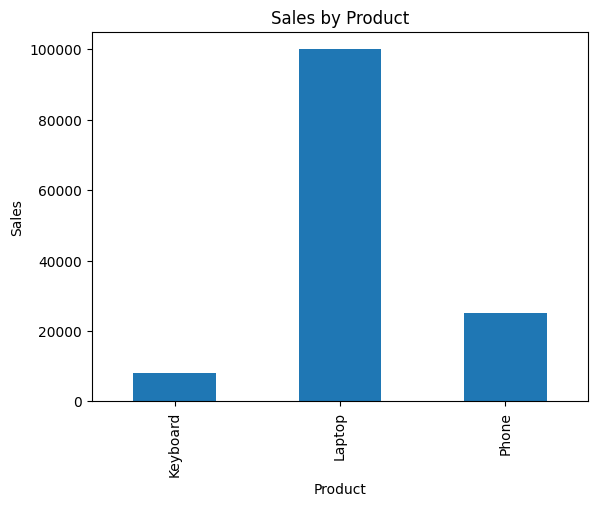

In [25]:
sales = df.groupby("Product")["Sales"].sum()

sales.plot(kind="bar")

plt.title("Sales by Product")

plt.xlabel("Product")

plt.ylabel("Sales")

plt.show()

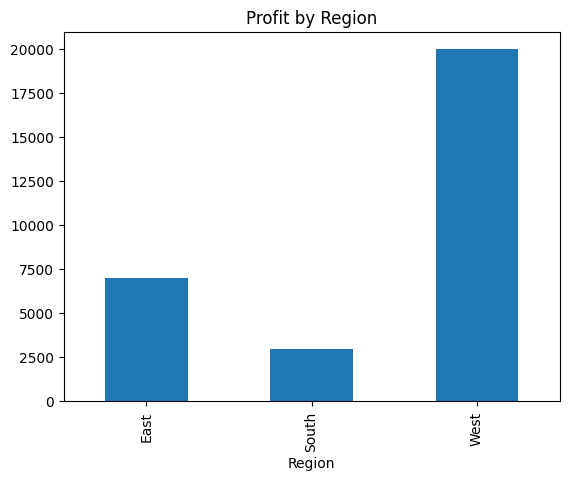

In [26]:
profit = df.groupby("Region")["Profit"].sum()

profit.plot(kind="bar")

plt.title("Profit by Region")

plt.show()

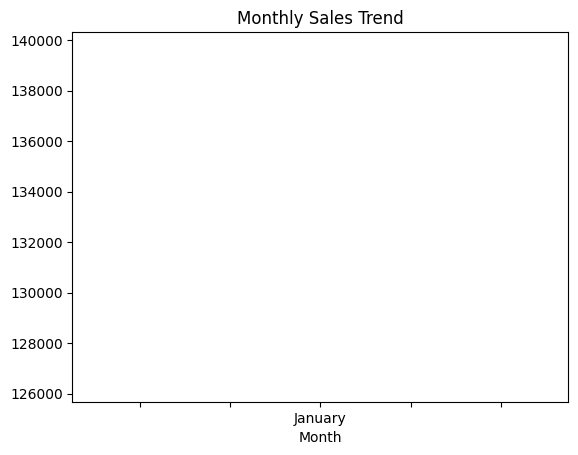

In [27]:
monthly = df.groupby("Month")["Sales"].sum()

monthly.plot(kind="line")

plt.title("Monthly Sales Trend")

plt.show()